# 08-Subgraphs：把大图拆成模块

Subgraph · 父图/子图接口 · 不同 state schema / 共享 state keys · 第八课 · 约 40 分钟

### 目录

-   回顾：我们已经能把图跑起来、还能让它可见/可存档
-   一、为什么需要 Subgraph？（工程拆分与复用）
-   二、两种通信方式：不同 state schema vs 共享 state keys
-   三、Demo 1：不同 state schema（在节点里 invoke 子图）
-   四、Demo 2：共享 state keys（把子图直接 add_node 到父图）
-   五、常见坑速查
-   六、总结

### 回顾：图越来越大，问题也越来越“工程化”

到目前为止，你已经能做出具备产品能力的图：

- 会选路（条件路由/Command）
- 会存档（Checkpointer）
- 能停下来等人（HIL）
- 能把过程直播出来（Streaming）

现在很自然会出现下一个问题：**图越来越大，怎么拆？**

- 不想把所有节点都堆在一个 notebook/一个文件里
- 希望“检索模块/审核模块/回复模块”能在多个图里复用
- 希望不同人/不同团队各自维护一块，只要接口对得上就能拼起来

Subgraph 就是为了解决这个问题。


### 一、为什么需要 Subgraph？（工程拆分与复用）

一句话：**子图就是“把一张图当成另一个图的一个节点”。**

> **类比：函数 vs 模块**
>
> - 小脚本里：你把逻辑写成一个函数就够了。
> - 工程里：你把一坨函数封装成模块，对外只暴露接口。
>
> Subgraph 就是图世界里的“模块”。

常见用法：

- 把一段固定流程封装起来（例如“检索 → 去重 → 摘要”）
- 多个图复用同一个子流程
- 多 agent 系统里，每个 agent 是一个子图


### 二、两种通信方式：不同 state schema vs 共享 state keys

官方文档把“父图和子图怎么对接”分成两种模式：

1. **不同 state schema**：父图和子图的 state key 完全不同（或你想做映射）。
   - 做法：写一个“包装节点”，在这个节点里 `subgraph.invoke(...)`。
2. **共享 state keys**：父图和子图用同一套 key（至少共享一部分 key）。
   - 做法：把编译后的子图直接传给 `add_node("某模块", subgraph)`，不需要包装函数。

这节课我们用两个 Demo 把这两种模式跑通。


In [1]:
import operator
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END


# 一个固定的“知识库”（离线可跑）
KB = {
    "退款": [
        "退款一般在 1-3 个工作日到账。",
        "大额退款需要人工复核。",
        "请保留订单号以便查询。",
    ],
    "发票": [
        "发票支持电子发票。",
        "电子发票会发送到你的邮箱。",
    ],
}

### 三、Demo 1：不同 state schema（在节点里 invoke 子图）

场景：父图只关心两个字段：

- `query`：用户问题
- `answer`：最终回答

但我们希望把“检索与摘要”封成一个子图，子图内部用自己的 state schema（`q/docs/summary`），父图完全不用知道它内部怎么跑。

这就是“不同 state schema”的典型用法。


In [2]:
# ---- 子图：检索 + 摘要（自己的 state schema）----
class RetrievalState(TypedDict):
    q: str
    docs: Annotated[list[str], operator.add]
    summary: str


def retrieve_docs(state: RetrievalState):
    q = state["q"]
    if "退款" in q:
        docs = KB["退款"]
    elif "发票" in q:
        docs = KB["发票"]
    else:
        docs = ["（未命中知识库）请提供订单号或更具体的问题。"]
    return {"docs": docs}


def summarize_docs(state: RetrievalState):
    summary = " ".join(state["docs"])
    return {"summary": summary}


sub_builder = StateGraph(RetrievalState)
sub_builder.add_node("检索", retrieve_docs)
sub_builder.add_node("摘要", summarize_docs)
sub_builder.add_edge(START, "检索")
sub_builder.add_edge("检索", "摘要")
sub_builder.add_edge("摘要", END)

subgraph_retrieval = sub_builder.compile()

# ---- 父图：只关心 query/answer ----
class ParentState(TypedDict):
    query: str
    answer: str


def call_retrieval_subgraph(state: ParentState):
    # 关键：在父图节点里“映射输入”到子图 state
    sub_out = subgraph_retrieval.invoke({"q": state["query"], "docs": [], "summary": ""})
    # 关键：把子图输出“映射回父图”
    return {"answer": f"根据知识库：{sub_out['summary']}"}


builder = StateGraph(ParentState)
builder.add_node("检索模块", call_retrieval_subgraph)
builder.add_edge(START, "检索模块")
builder.add_edge("检索模块", END)

graph_parent = builder.compile()

print(graph_parent.invoke({"query": "退款多久到账？", "answer": ""}))

{'query': '退款多久到账？', 'answer': '根据知识库：退款一般在 1-3 个工作日到账。 大额退款需要人工复核。 请保留订单号以便查询。'}



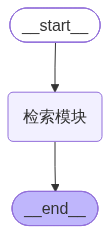


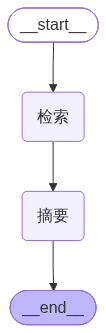

In [3]:
import base64

from IPython.display import HTML, display
from langchain_core.runnables.graph import MermaidDrawMethod


def display_centered_png(png_bytes: bytes, caption: str):
    b64 = base64.b64encode(png_bytes).decode("ascii")
    display(
        HTML(
            f"""
<div style=\"text-align:center;\">
  <img
    src=\"data:image/png;base64,{b64}\"
    style=\"display:block; margin: 0 auto; max-width: 100%; height: auto;\"
  />
  <div style=\"text-align:center; margin-top: 6px;\">{caption}</div>
</div>
"""
        )
    )


display_centered_png(
    graph_parent.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API),
    "图：父图（把子图封装成一个“模块节点”）",
)

display_centered_png(
    subgraph_retrieval.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API),
    "图：子图（检索 → 摘要）",
)

> **❓ 检查理解 ①**
>
> Demo 1 里，父图为什么不直接把子图 `add_node("检索模块", subgraph_retrieval)`？
>
> -   A. 因为父图和子图的 state schema 不同，需要做输入/输出映射
> -   B. 因为子图不能被 add_node
> -   C. 因为子图必须用 stream_events 才能调用
>
> **✅ 答案：A**
>
> 父图的 key 是 `query/answer`，子图的 key 是 `q/docs/summary`。如果直接 add_node，就没有地方做映射。


### 四、Demo 2：共享 state keys（把子图直接 add_node 到父图）

第二种模式更“爽”：父图和子图共享同一套 key（至少共享一部分）。

此时你可以把**编译后的子图**直接当成父图的一个节点：

- `builder.add_node("检索模块", subgraph)`

父图不用写包装函数，子图会直接读写父图的 state。


In [4]:
# 共享 state keys：父图/子图都用同一套 state（离线可跑）
class SharedState(TypedDict):
    query: str
    docs: Annotated[list[str], operator.add]
    answer: str


def retrieve_shared(state: SharedState):
    q = state["query"]
    if "退款" in q:
        docs = KB["退款"]
    elif "发票" in q:
        docs = KB["发票"]
    else:
        docs = ["（未命中知识库）请提供订单号或更具体的问题。"]
    return {"docs": docs}


def answer_shared(state: SharedState):
    return {"answer": " ".join(state["docs"])}


sub2 = StateGraph(SharedState)
sub2.add_node("检索", retrieve_shared)
sub2.add_node("回答", answer_shared)
sub2.add_edge(START, "检索")
sub2.add_edge("检索", "回答")
sub2.add_edge("回答", END)
subgraph_shared = sub2.compile()


def finalize_parent(state: SharedState):
    return {"answer": f"根据知识库：{state['answer']}"}


parent2 = StateGraph(SharedState)
parent2.add_node("知识模块", subgraph_shared)
parent2.add_node("收尾", finalize_parent)
parent2.add_edge(START, "知识模块")
parent2.add_edge("知识模块", "收尾")
parent2.add_edge("收尾", END)

graph_parent2 = parent2.compile()

out = graph_parent2.invoke({"query": "发票怎么开？", "docs": [], "answer": ""})
print(out)

{'query': '发票怎么开？', 'docs': ['发票支持电子发票。', '电子发票会发送到你的邮箱。'], 'answer': '根据知识库：发票支持电子发票。 电子发票会发送到你的邮箱。'}



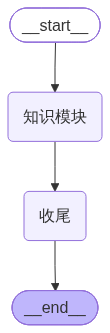

In [5]:
from langchain_core.runnables.graph import MermaidDrawMethod


display_centered_png(
    graph_parent2.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API),
    "图：父图直接把子图当成一个节点（共享 state keys）",
)

> **❓ 检查理解 ②**
>
> Demo 2 里，如果你希望子图写入 `docs` 时“累加而不是覆盖”，父图的 `docs` 字段需要什么？
>
> -   A. 什么都不需要，默认就是累加
> -   B. 需要 reducer（例如 `Annotated[list[str], operator.add]`）
> -   C. 需要把 docs 改成 set
>
> **✅ 答案：B**
>
> 共享 key 的合并规则由父图 state schema 决定：不写 reducer 就默认覆盖；写了 reducer 才会按 reducer 合并。


### 五、常见坑速查

| 症状 | 原因 | 解法 |
| --- | --- | --- |
| 父图和子图 state key 对不上，直接 add_node 运行就报错 | 你本质上需要做“输入/输出映射” | 用 Demo 1 的做法：写包装节点，在节点里 invoke 子图 |
| 子图写了父图的某个共享 key，但结果丢了/被覆盖 | 父图该 key 没配置 reducer（默认覆盖）或被后续节点覆盖 | 给共享 key 配 reducer；或明确后续节点的写入策略 |
| 想在子图里“跳回父图另一个节点”做路由 | 没搞清楚 subgraph 的边界 | 需要用 `Command(graph=Command.PARENT, goto=...)`（进阶用法，后面再学） |
| 子图到底执行了哪些内部节点看不清 | 你只看了父图的图 | 用子图自己的 `draw_mermaid_png()` 单独画；需要更细粒度可配合 streaming/events（后面工程化再展开） |

### 六、总结

| 概念 | 一句话解释 | 类比 |
| --- | --- | --- |
| Subgraph | 一张图作为另一张图的一个节点 | 模块/子系统 |
| 不同 state schema | 通过包装节点 invoke 子图，手写映射 | 适配器/DTO 转换 |
| 共享 state keys | 直接 `add_node("模块", subgraph)` | 模块共享同一份状态对象 |

> **一句话总结**
>
> **小图先封装成子图，大图再组装成父图**：父图管“编排”，子图管“实现”。


📖 参考：

-   [LangGraph 官方文档 - Subgraphs](https://docs.langchain.com/oss/python/langgraph/use-subgraphs)
-   [LangGraph 官方文档 - Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
-   [LangGraph 官方文档 - Use Graph API](https://docs.langchain.com/oss/python/langgraph/use-graph-api)
